In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du fichier CSV
df = pd.read_csv('car data.csv')

# Affichage des 5 premières lignes
print("--- Aperçu des données ---")
df.head()

--- Aperçu des données ---


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
# Informations générales
print("--- Informations sur le dataset ---")
df.info()

print("\n--- Vérification des valeurs manquantes ---")
print(df.isnull().sum())

print("\n--- Statistiques descriptives ---")
df.describe()

--- Informations sur le dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

--- Vérification des valeurs manquantes ---
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

--- Statistiques descriptives ---


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
# 1. Calcul de l'âge de la voiture
current_year = 2026
df['Age'] = current_year - df['Year']

# Supprimer la colonne 'Year' (remplacée par Age) et 'Car_Name'
df_processed = df.drop(['Year', 'Car_Name'], axis=1)

# 2. Encodage des variables catégorielles (Fuel_Type, Selling_type, Transmission)
df_processed = pd.get_dummies(df_processed, drop_first=True)

# Afficher le dataset nettoyé
df_processed.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split

# Variable cible (y) et variables explicatives (X)
X = df_processed.drop('Selling_Price', axis=1)
y = df_processed['Selling_Price']

# Séparation 80% entraînement / 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de X_train : {X_train.shape}")
print(f"Taille de X_test : {X_test.shape}")

Taille de X_train : (240, 8)
Taille de X_test : (61, 8)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Entraînement du modèle
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

# Évaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Résultats du Modèle ===")
print(f"Score R² : {r2:.4f} (soit {r2*100:.2f}% de précision)")
print(f"Erreur Absolue Moyenne (MAE) : {mae:.4f}")
print(f"Racine de l'Erreur Quadratique Moyenne (RMSE) : {rmse:.4f}")

=== Résultats du Modèle ===
Score R² : 0.9595 (soit 95.95% de précision)
Erreur Absolue Moyenne (MAE) : 0.6369
Racine de l'Erreur Quadratique Moyenne (RMSE) : 0.9664


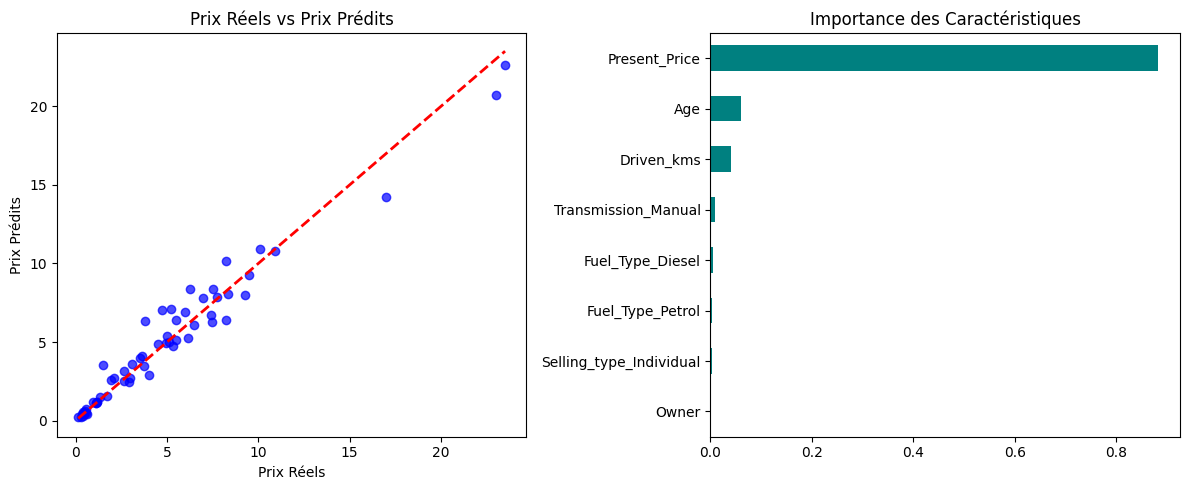

In [ ]:
plt.figure(figsize=(12, 5))

# Graphique 1 : Prix Réels vs Prix Prédits
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Prix Réels')
plt.ylabel('Prix Prédits')
plt.title('Prix Réels vs Prix Prédits')

# Graphique 2 : Importance des fonctionnalités
plt.subplot(1, 2, 2)
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', color='teal')
plt.title('Importance des Caractéristiques')

plt.tight_layout()
plt.show()